## About the Notebook:

This analysis explores spatial and environmental factors associated with river water quality. Satellite imagery from climate variables, such as Potential Evapotranspiration (PET) were incorporated to provide broader environmental context around observed water quality conditions and reflect underlying climatic influences.

The analysis focuses on data collected between 2011 and 2015. Relevant satellite and climate features were retrieved using API-based access through the Microsoft Planetary Computer portal and combined with water quality observations. Together, these datasets support an exploratory assessment of three key water quality parameters: Total Alkalinity (TA), Electrical Conductance (EC), and Dissolved Reactive Phosphorus (DRP).

In this notebook I'll explore how spatial conditions affect water quality over time.

```%pip install geopandas folium seaborn watermark```

In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import MultiPolygon, Point
import folium
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

sns.set_theme()

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

%load_ext watermark
%watermark -v
%watermark --iversions

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.4.0

matplotlib: 3.10.5
seaborn   : 0.13.2
folium    : 0.20.0
geopandas : 1.1.2
pandas    : 2.3.1
shapely   : 2.1.2



In [2]:
df = pd.read_pickle('data/good_vs_bad.pkl')
# df = pd.read_csv('data/wq.csv')
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

# https://simplemaps.com/gis/country/za --> download shapefile
# https://simplemaps.com/static/svg/country/za/admin1/za_shp.zip
path_to_data = 'data/za_shp'
provinces = gpd.read_file(path_to_data, layer='za').to_crs("EPSG:4326")
provinces = provinces.rename(columns={'name':'province'}).sort_values(by='province')

I broke down and had to ask AI how to do the next step <a href="https://search.brave.com/ask?q=poly+geometry+column+attributes+geopandas&source=quick-answer-followup&quickAnswerKey=08b6a94cb59b797c37ab73c2288ac22f4a90&quickAnswerQuery=poly+geometry+column+attributes+geopandas&conversation=08b68984eb40a57f229ccbefc071d17a3b3c">here</a>, and promted it as such, "how to convert a list of polygon into a multipolygon".

In [3]:
# replace the Western Cape with just the main land part without PRINCE EDWARDS ISLANDS
new_polygon = provinces['geometry'].explode()[7][:1]
multipolygon = MultiPolygon(new_polygon)
provinces.loc[7, 'geometry'] = multipolygon
provinces

,id,province,source,geometry
3,ZAEC,Eastern Cape,https://simplemaps.com,"POLYGON ((24.14703 -31.78989, 24.15432 -31.758..."
2,ZAFS,Free State,https://simplemaps.com,"POLYGON ((25.46747 -30.61312, 25.43161 -30.592..."
8,ZAGP,Gauteng,https://simplemaps.com,"POLYGON ((28.25583 -26.8936, 28.24466 -26.8940..."
1,ZAKZN,KwaZulu-Natal,https://simplemaps.com,"POLYGON ((30.19597 -31.07789, 30.1925 -31.0729..."
4,ZALP,Limpopo,https://simplemaps.com,"POLYGON ((31.85649 -23.96296, 31.85623 -23.963..."
6,ZAMP,Mpumalanga,https://simplemaps.com,"POLYGON ((31.24471 -27.23259, 31.18764 -27.297..."
5,ZANW,North West,https://simplemaps.com,"POLYGON ((25.01349 -28.06821, 25.00512 -28.070..."
0,ZANC,Northern Cape,https://simplemaps.com,"POLYGON ((22.63695 -26.11428, 22.70516 -26.129..."
7,ZAWC,Western Cape,https://simplemaps.com,"MULTIPOLYGON (((17.76711 -31.15581, 17.76742 -..."


### Grouping water quality parameters by province and aggregate by taking the mean in each province

Evapotranspiration is the combined process of how moisture is transferred from land into the atmosphere.
This metric is often related to weather, climate & **water availability**.
- evaporation: water from the Earth's surface
- transpiration: water vapor from plants

Evapotranspiration measurements may reflect temperature, humidity and vegetation type in any given region.  
Normally Potential Evapotranspiration is measured in mm/day for our dataset.  

https://en.wikipedia.org/wiki/Potential_evapotranspiration  
https://planetarycomputer.microsoft.com/dataset/terraclimate#overview

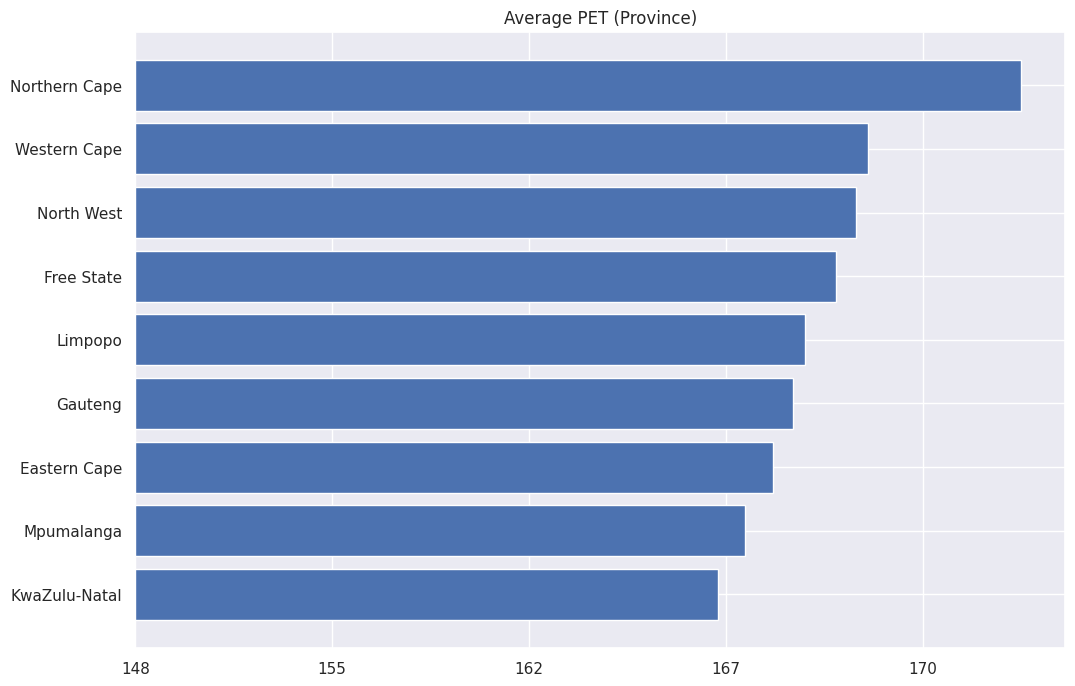

In [25]:
def piv(df, x='province', y='pet', by='province'):
    '''
    input
    -----
    x: str; column name of pandas dataframe
    y: str; column name of pandas dataframe

    returns
    -------
    pandas dataframe pivot grouped by x and values sorted by y
    '''
    df = df[[x, y]].groupby(x).mean().sort_values(by=by, ascending=True)
    # df = df.sort_values(by=y, ascending=True)
    df = df[y].round().astype(int)
    return df.reset_index()

#gdf[['province', 'electrical conductance']].groupby('province').mean().sort_values(by='province').reset_index()

def bar_horizontal(df, x='province', y='pet', title=str):
    '''
    input
    -----
    x: str; column name of pandas dataframe
    y: str; column name of pandas dataframe

    returns
    -------
    matplotlib horizontal bar plot
    '''
    fig, ax = plt.subplots(figsize=(12, 8))
    plt.barh(df[x], df[y].round().astype(int))
    ax.set_xticklabels(labels=df[y])
    plt.get_cmap('viridis')
    plt.title(title)

ax2 = bar_horizontal(piv(gdf, by='pet'), title='Average PET (Province)')

In [5]:
# Group mean EC with each province (sort by province to 
province_group_EC = piv(df, x='province', y='electrical conductance', by='province')
province_group_EC

,province,electrical conductance
0,Eastern Cape,243
1,Free State,561
2,Gauteng,622
3,KwaZulu-Natal,240
4,Limpopo,475
5,Mpumalanga,374
6,North West,727
7,Northern Cape,633
8,Western Cape,494


In [6]:
# Add aggregated EC data to each provice
provinces = provinces.merge(province_group_EC, on='province')
provinces

,id,province,source,geometry,electrical conductance
0,ZAEC,Eastern Cape,https://simplemaps.com,"POLYGON ((24.14703 -31.78989, 24.15432 -31.758...",243
1,ZAFS,Free State,https://simplemaps.com,"POLYGON ((25.46747 -30.61312, 25.43161 -30.592...",561
2,ZAGP,Gauteng,https://simplemaps.com,"POLYGON ((28.25583 -26.8936, 28.24466 -26.8940...",622
3,ZAKZN,KwaZulu-Natal,https://simplemaps.com,"POLYGON ((30.19597 -31.07789, 30.1925 -31.0729...",240
4,ZALP,Limpopo,https://simplemaps.com,"POLYGON ((31.85649 -23.96296, 31.85623 -23.963...",475
5,ZAMP,Mpumalanga,https://simplemaps.com,"POLYGON ((31.24471 -27.23259, 31.18764 -27.297...",374
6,ZANW,North West,https://simplemaps.com,"POLYGON ((25.01349 -28.06821, 25.00512 -28.070...",727
7,ZANC,Northern Cape,https://simplemaps.com,"POLYGON ((22.63695 -26.11428, 22.70516 -26.129...",633
8,ZAWC,Western Cape,https://simplemaps.com,"MULTIPOLYGON (((17.76711 -31.15581, 17.76742 -...",494


### Total Alkalinity & Electrical Conductance

- Total Alkalinity
    - Resistance to pH fluctuation often measured by buffer concentrations of CaCO3 (or similar titrant) in milligrams per liter or ppm. 
    -  Ideal Range: 20 to 200 mg/L

- Electrical Conductance
    - Hoow easily electric current flows through a specific object or component measured in micro-Siemens per centimeter
    - Ideal Range: < 800 uS/cm

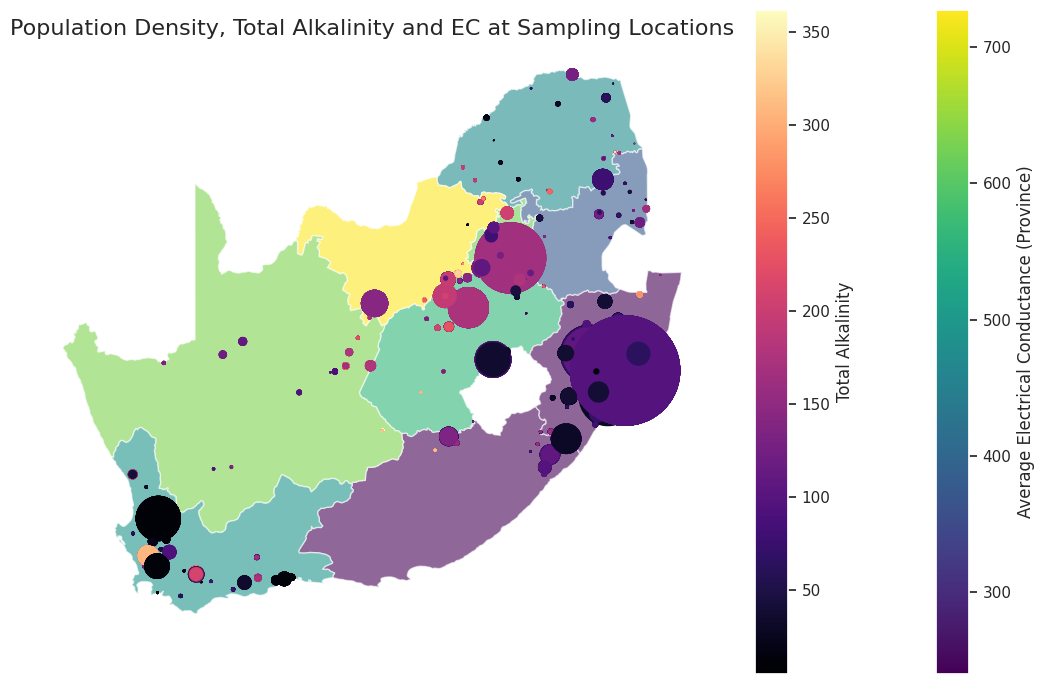

In [7]:
import matplotlib.pyplot as plt

# Plot
fig, ax = plt.subplots(figsize=(11, 7))

ax1 = provinces.plot(column='electrical conductance', ax=ax, zorder=1, cmap='viridis', alpha=0.6, legend=True, legend_kwds={'label':'Average Electrical Conductance (Province)'})#, tootip={'province'})
ax1 = gdf.plot(column='total alkalinity', ax=ax, marker='o', markersize=gdf['pop_density_nn'], zorder=2, cmap='magma', legend=True, legend_kwds={'label':'Total Alkalinity'})#, tootip={'pop_density_nn'})

ax.set_axis_off()
plt.title('Population Density, Total Alkalinity and EC at Sampling Locations', fontsize=16)
plt.tight_layout()
plt.show()

#### It looks like Total Alkalinity and Electrical Conductance have a general positive correlation

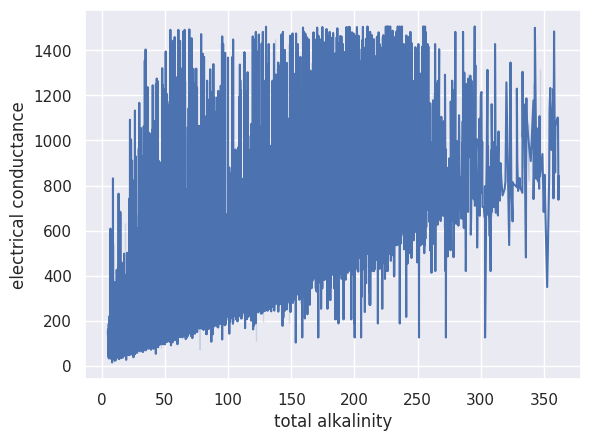

In [27]:
sns.lineplot(data=gdf, x="total alkalinity", y="electrical conductance");

### How are our parameters looking throughout time??

- LET's GO FOR SPEED!!!
- Here we can explore ways to analyze PET, and other water quality parameters if we want.

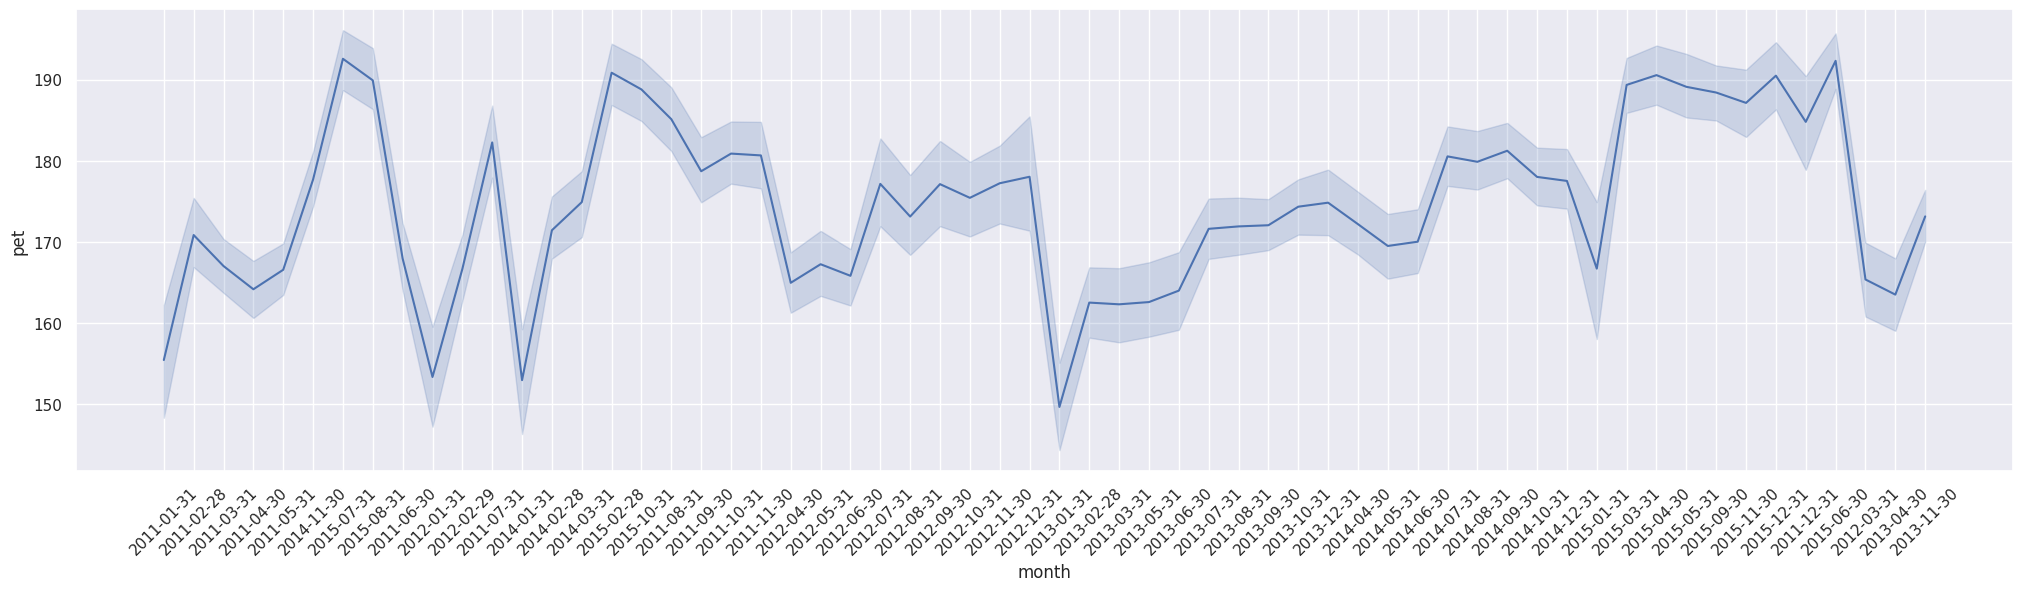

In [44]:
# Monthly time series vs PET
fig, ax = plt.subplots(figsize=(25, 6));
sns.lineplot(data=gdf, x="month", y="pet")
plt.xticks(rotation=45);

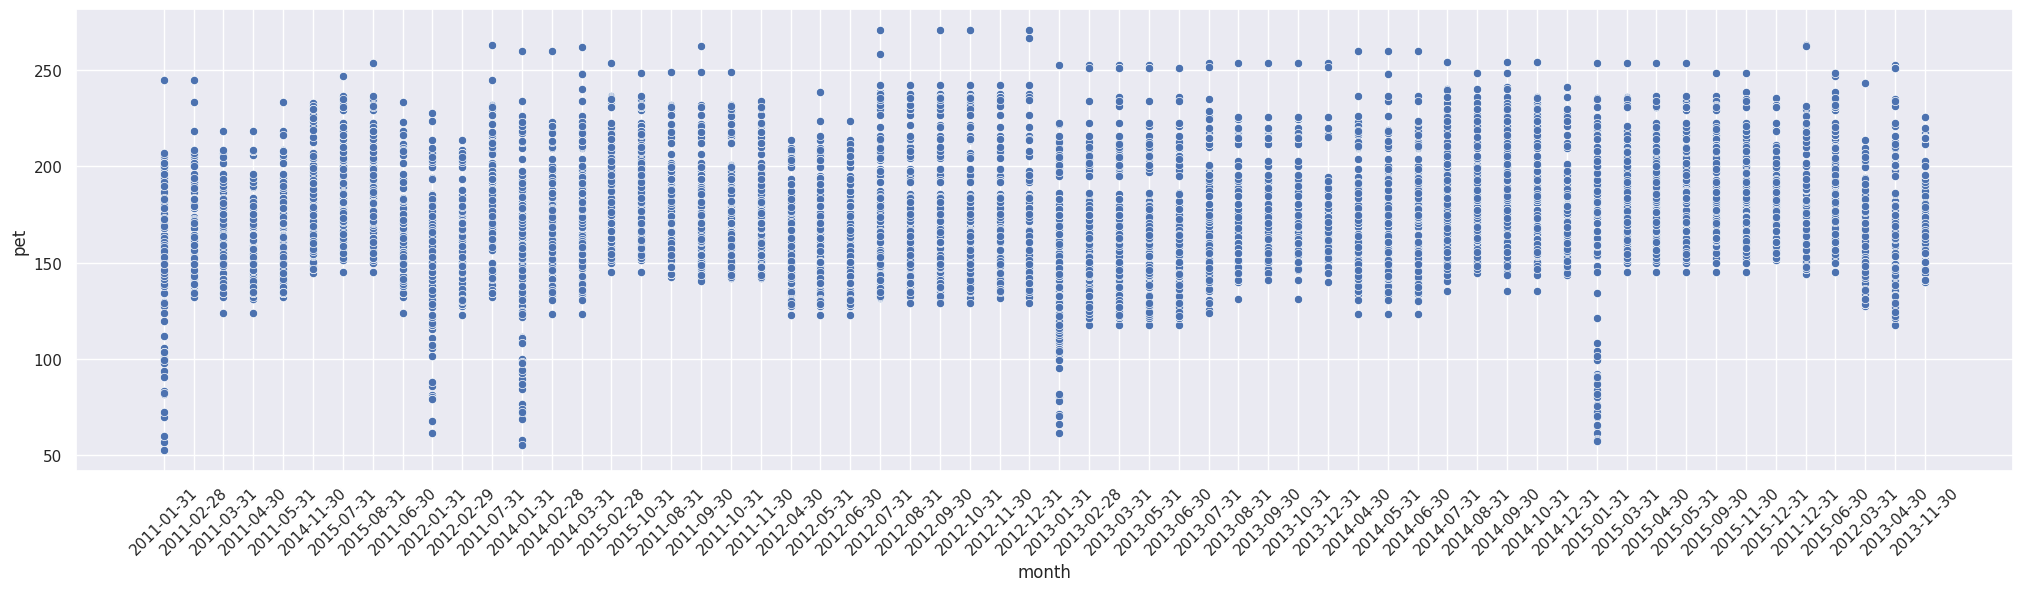

In [43]:
fig, ax = plt.subplots(figsize=(25, 6));
sns.scatterplot(data=gdf, x="month", y="pet")
plt.xticks(rotation=45);

In [14]:
gdf.columns

Index(['country', 'latitude', 'longitude', 'sample date', 'nir', 'green',
       'swir16', 'swir22', 'ndmi', 'mndwi', 'pet', 'total alkalinity',
       'electrical conductance', 'dissolved reactive phosphorus', 'month',
       'province', 'sample_year', 'pop_density_nn', 'distance_km_to_pd_cell',
       'river_mouth', 'river_junction', 'river_mouthORjunction', 'DRP', 'EC',
       'Alkalinity', 'how_good', 'good', 'bad', 'geometry'],
      dtype='object')

In [19]:
pivot_table = gdf[['nir', 'green','swir16', 'swir22', 'ndmi', 'mndwi', 'pet', 'total alkalinity',
       'electrical conductance', 'dissolved reactive phosphorus', 'month']].groupby('month').sum().astype(int)

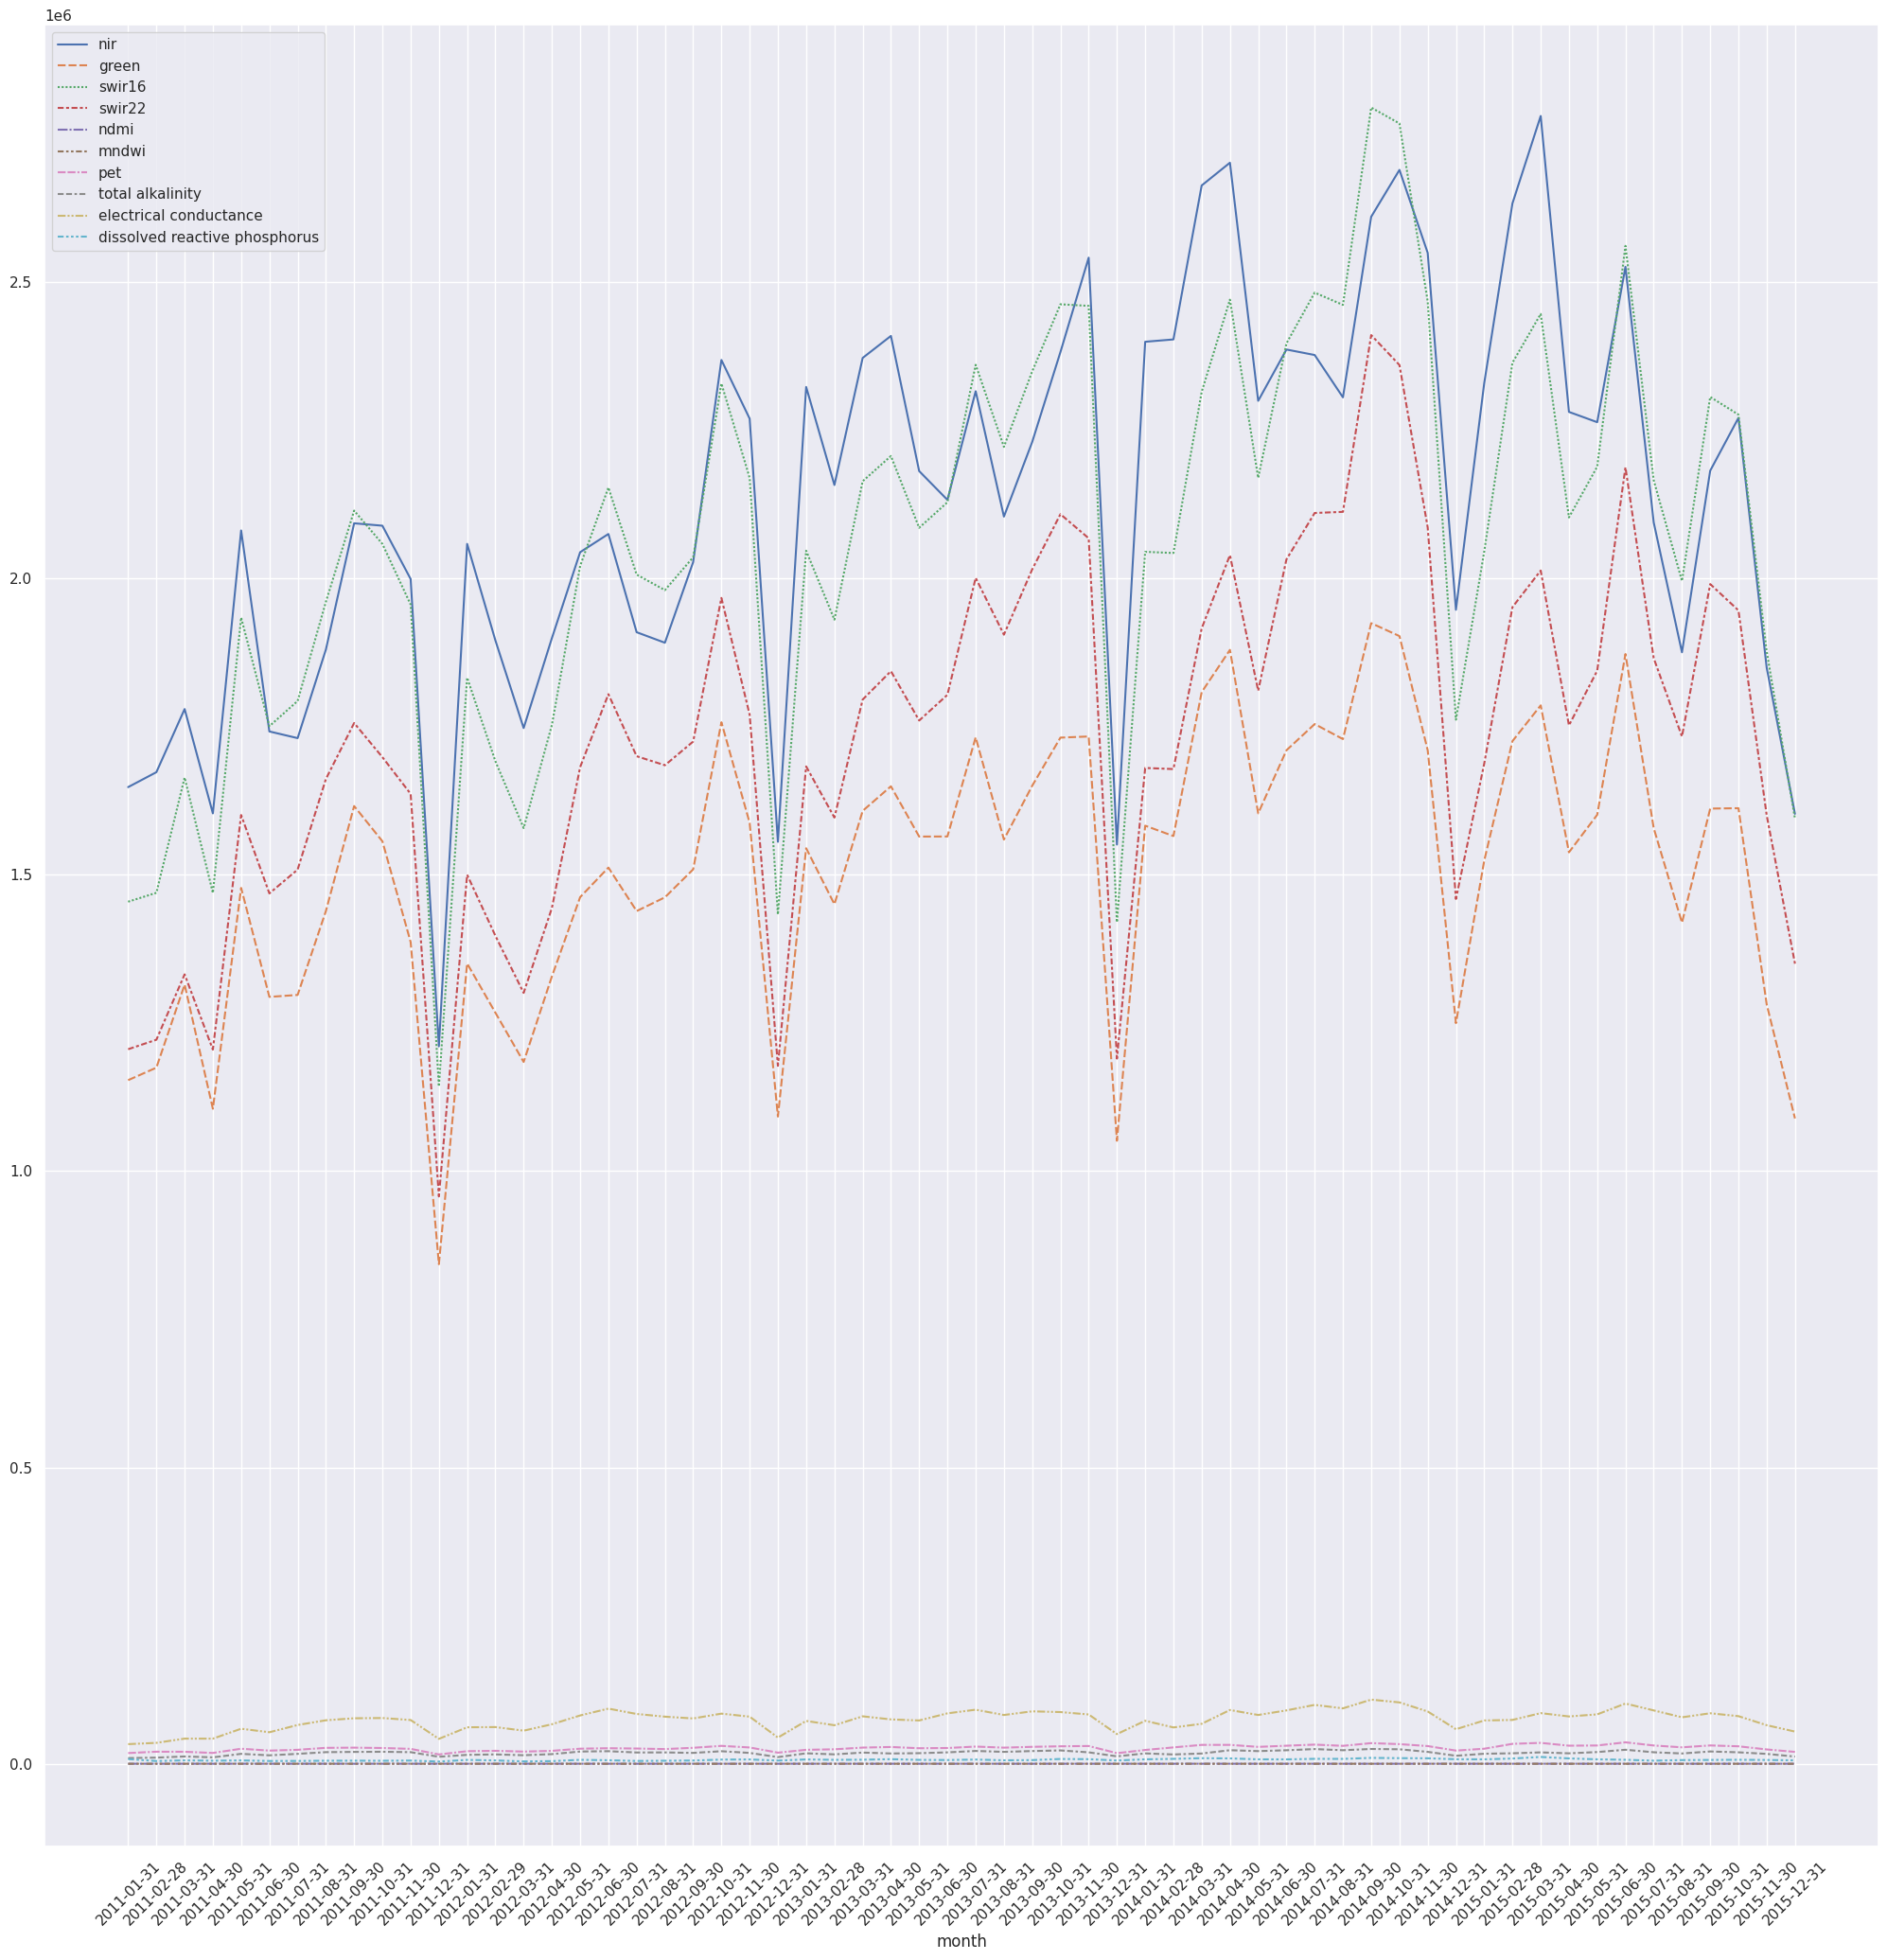

In [45]:
fig, ax = plt.subplots(figsize=(25, 25));
sns.lineplot(data=pivot_table)
plt.xticks(rotation=45);